In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from matplotlib.cm import get_cmap

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [30]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # sensor modality
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npz" , allow_pickle=True))

            else:
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npz" , allow_pickle=True))

    # print(dataset)
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [ ]:
NUM_POLICY = 5
# Hebb vs CPG
# mode=["full","vel_act", "pos_act", "pos_vel_act", "act_FC", "act_IMU_FC", "pos_act_IMU", "pos_act_FC", "vel_act_IMU", "vel_act_FC" , "CPG_RBF"]
# Hebb only
# mode=["full","vel_act", "pos_acvel
mode = ["vel",'pos_action','vel_action','pos_vel_action','vel_imu','pos_action_imu','vel_action_imu',
 'pos_vel_action_imu','vel_fc','action_fc','vel_action_fc','pos_vel_action_fc','vel_imu_fc',
 'pos_vel_imu_fc','action_imu_fc','vel_action_imu_fc','pos_vel_action_imu_fc']

slope_10    =   import_data(mode , NUM_POLICY , case="slope",level=-10)
slope10     =   import_data(mode , NUM_POLICY , case="slope",level=10)

mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)


# flat        =   import_data(mode , NUM_POLICY , case="flat")
rough       =   import_data(mode , NUM_POLICY , case="rough")
morph       =   import_data(mode , NUM_POLICY , case="morph")

slope_list      = [slope10 ,slope_10 ] # The 15 is slip so the result is shown in not significant way. [slope5 , slope10 , slope15 , slope_5 , slope_10 ,  slope_15]
slope_list_str  = ["slope10" , "slope_10"]


mass_list       = [mass1000] # [mass250 , mass500 , mass1000 , mass2000 , mass5000 , mass10000
mass_list_str   = ["mass1000"]
# [case:str][number_file:int][data/brain:str]

FileNotFoundError: [Errno 2] No such file or directory: '../data/data_2026/HEBB-vel-0-bend-flat.npy'

## Preprocess Data

In [ ]:
def preprocess(selected_dataset , num_pol):
    performance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    max_distance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    avg_vel = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}

    for policy in range(num_pol):
        for case in selected_dataset.keys():
            reward = np.sum(selected_dataset[case][policy]["data"]['reward'], axis=0)
            performance[f"policy{policy}"][case] = reward

            max_pos_x = np.max(selected_dataset[case][policy]["data"]['pos_x'], axis=0)
            max_distance[f"policy{policy}"][case] = max_pos_x

            vel_x = selected_dataset[case][policy]["data"]['vel_b'][:,:,0]
            avg_vel[f"policy{policy}"][case] = np.mean(vel_x ,axis=0)
    return performance , max_distance , avg_vel

def preprocess_combined(selected_dataset, num_pol):
    """
    Combine values from ALL policies into one 'policy_all' per case.

    Returns:
        performance_all, max_distance_all, avg_vel_all
        # Each is a dict like:
        # {
        #   'policy_all': {
        #       <case_a>: np.ndarray(... concatenated from all policies ...),
        #       <case_b>: np.ndarray(...),
        #       ...
        #   }
        # }
    """
    cases = list(selected_dataset.keys())

    # Buckets (lists) to collect per-policy arrays before concatenating
    perf_bucket = {case: [] for case in cases}
    dist_bucket = {case: [] for case in cases}
    vel_bucket  = {case: [] for case in cases}

    for policy in range(num_pol):
        for case in cases:
            # data = selected_dataset[case][policy]["data"]
            data = selected_dataset[case][policy]
            # print(case , data.keys())
            # 1) reward sum over time -> shape (..., ?) then flatten along new axis 0
            # print(data.keys())
            reward = np.sum(data["reward"], axis=0)
            perf_bucket[case].append(np.ravel(reward))

            # 2) max pos_x over time
            max_pos_x = np.max(data["pos_x"], axis=0)
            dist_bucket[case].append(np.ravel(max_pos_x))

            # 3) avg vel_x over time (take x component from vel_b[..., 0])
            vel_x = data["vel_b"][:, :, 0]
            avg_vel_x = np.mean(vel_x, axis=0)
            vel_bucket[case].append(np.ravel(avg_vel_x))

    # Concatenate across all policies so each case has one long vector
    performance_all = {"policy": {case: np.concatenate(perf_bucket[case], axis=0) if len(perf_bucket[case]) else np.array([]) for case in cases}}
    max_distance_all = {"policy": {case: np.concatenate(dist_bucket[case], axis=0) if len(dist_bucket[case]) else np.array([]) for case in cases}}
    avg_vel_all = {"policy": {case: np.concatenate(vel_bucket[case], axis=0) if len(vel_bucket[case]) else np.array([]) for case in cases}}

    return performance_all, max_distance_all, avg_vel_all

In [ ]:
from matplotlib.colors import to_rgb

def _pastel_colors(n):
    """Generate n pastel-ish colors by blending tab10 with white."""
    base = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
            "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
    blend = []
    for i in range(n):
        r, g, b = to_rgb(base[i % len(base)])
        r = 0.7*1.0 + 0.3*r
        g = 0.7*1.0 + 0.3*g
        b = 0.7*1.0 + 0.3*b
        blend.append((r, g, b))
    return blend

def plot_case_boxplot(
    metric_all: dict,
    policy_key: str = "policy",
    title: str = "Distribution by Case",
    ylabel: str = "",
    ylim: list=[0,5],
    rotate_xticks: int = 30,
    notch: bool = False,
    showfliers: bool = True,
    savepath: str | None = None,
    show: bool = True,
    # --- pastel boxes ---
    pastel: bool = True,
    pastel_alpha: float = 0.9,
    # --- jittered points ---
    show_points: bool = True,
    jitter: float = 0.08,      # stddev of x-jitter (in axis units)
    point_size: float = 8,
    point_alpha: float = 0.6,
    rng_seed: int | None = None,
):
    """
    Plot one pastel-filled box per case and overlay jittered points.

    Expects: metric_all = { "policy": { caseA: np.ndarray, caseB: np.ndarray, ... } }
    Returns: (fig, ax)
    """
    if policy_key not in metric_all:
        raise KeyError(f"Expected key '{policy_key}' in metric_all. Got keys: {list(metric_all.keys())}")

    case_map = metric_all[policy_key]

    cases, data = [], []
    for case, arr in case_map.items():
        arr = np.asarray(arr)
        if arr.size == 0:
            continue
        cases.append(case)
        data.append(arr)

    if len(data) == 0:
        raise ValueError("No non-empty case arrays found to plot.")

    rng = np.random.default_rng(rng_seed)

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(
        data,
        tick_labels=cases,
        notch=notch,
        showfliers=showfliers,
        vert=True,
        patch_artist=True,  # needed to fill boxes
        medianprops={"color": "black", "linewidth": 1.4},
        whiskerprops={"color": "black", "linewidth": 1.0},
        capprops={"color": "black", "linewidth": 1.0},
    )

    # --- Pastel fill ---
    if pastel:
        colors = _pastel_colors(len(data))
        for box, c in zip(bp["boxes"], colors):
            box.set(facecolor=c, edgecolor="black", alpha=pastel_alpha, linewidth=1.0)

    # --- Jittered points overlay ---
    if show_points:
        # clip jitter inside the box’s general x-span
        clip_half_width = 0.35
        for i, arr in enumerate(data, start=1):
            xj = i + rng.normal(0.0, jitter, size=arr.size)
            xj = np.clip(xj, i - clip_half_width, i + clip_half_width)
            ax.scatter(
                xj, arr,
                s=point_size,
                alpha=point_alpha,
                edgecolors="none",
                zorder=3
            )

    # Titles & labels
    ax.tick_params(axis='x', labelsize=14)  # Set x-axis tick label size
    ax.tick_params(axis='y', labelsize=14)  # Set y-axis tick label size
    ax.set_title(title, fontsize=16)
    ax.set_ylabel(ylabel)
    if ylim != 0:
        ax.set_ylim([ ylim[0] , ylim[1]])
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    if rotate_xticks:
        for tick in ax.get_xticklabels():
            tick.set_rotation(rotate_xticks)
            tick.set_ha("right")

    # annotate mean (3 decimals)
    y_min = ax.get_ylim()[0]
    y_max = ax.get_ylim()[1]
    for i, arr in enumerate(data, start=1):
        ax.text(i, y_max-1, f"μ={arr.mean():.3f}", ha="center", va="bottom", fontsize=12)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

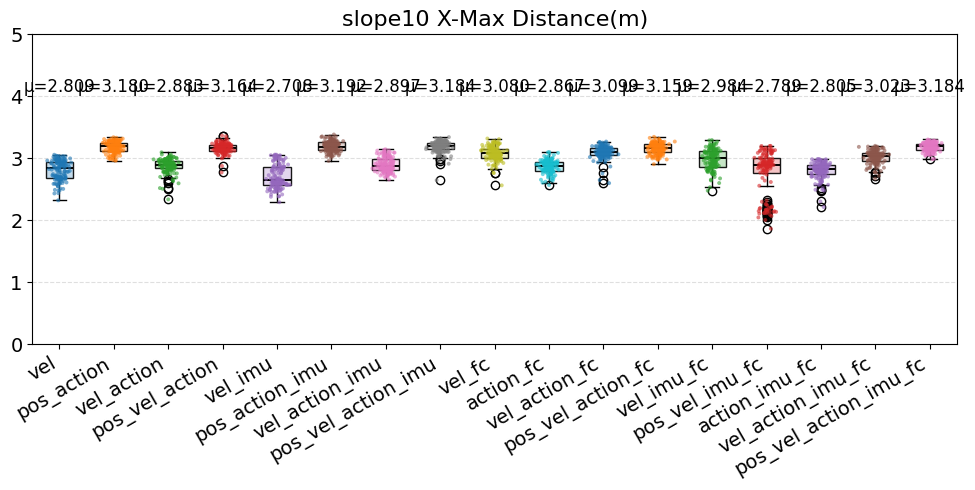

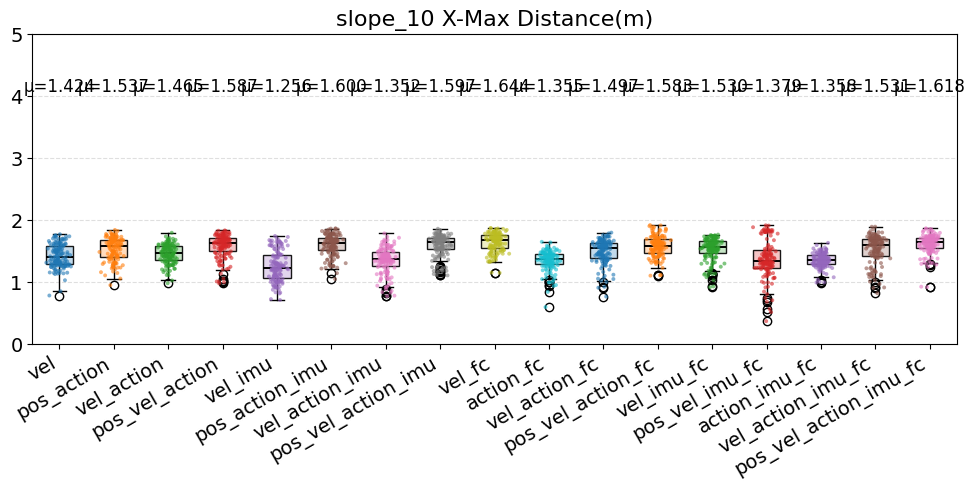

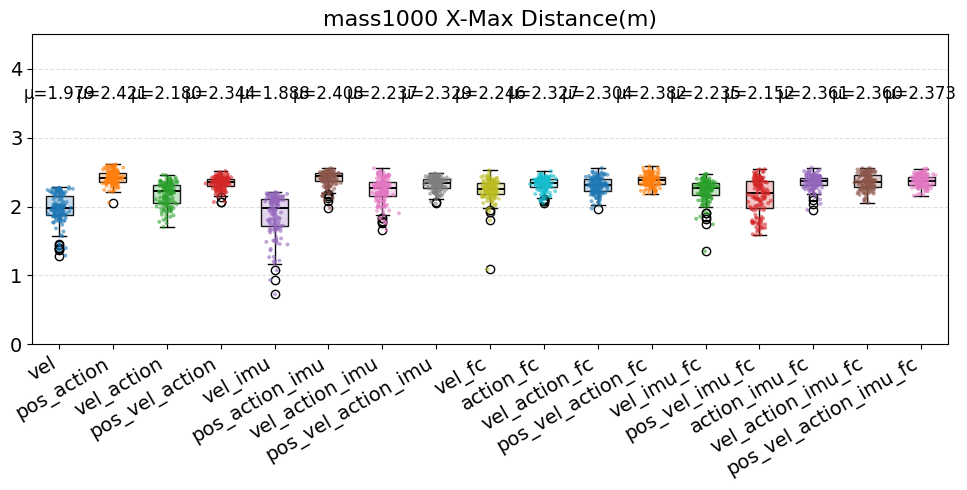

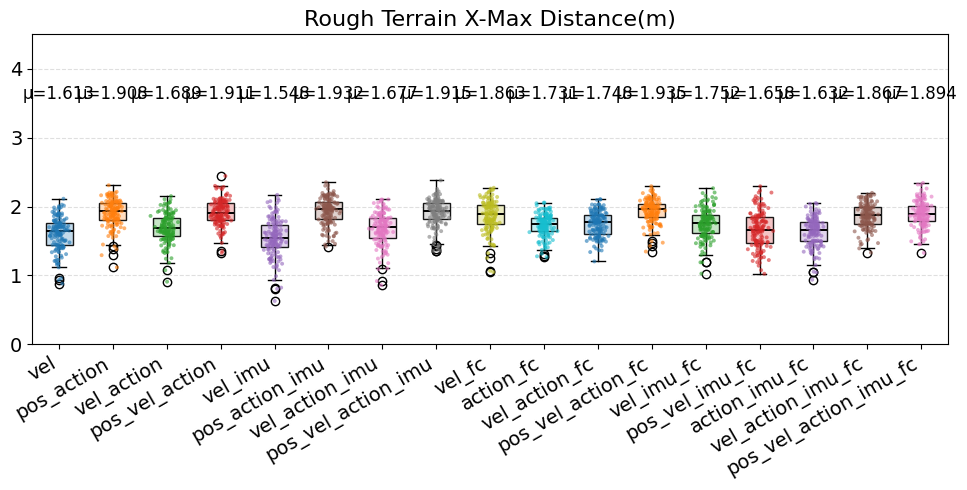

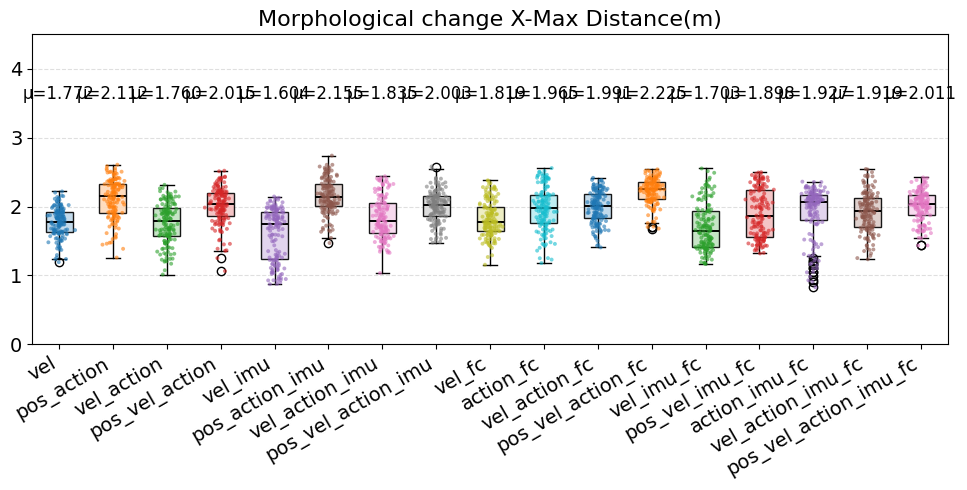

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Morphological change X-Max Distance(m)'}>)

In [ ]:
num_pol = 5
max_distance = {}
reward = {}
avg_vel = {}

# Get performance criteria
# Slope data
for idx , slope_data in enumerate(slope_list):
    reward[slope_list_str[idx]] , max_distance[slope_list_str[idx]] , avg_vel[slope_list_str[idx]]= preprocess_combined(selected_dataset=slope_data , num_pol=num_pol)

# Mass data
for idx , mass_data in enumerate(mass_list):
    reward[mass_list_str[idx]] , max_distance[mass_list_str[idx]] , avg_vel[mass_list_str[idx]]= preprocess_combined(selected_dataset=mass_data , num_pol=num_pol)

reward["flat"] , max_distance["flat"] , avg_vel["flat"] = preprocess_combined(selected_dataset=flat , num_pol=num_pol)
reward["rough"] , max_distance["rough"] , avg_vel["rough"] = preprocess_combined(selected_dataset=rough , num_pol=num_pol)
reward["morph"] , max_distance["morph"] , avg_vel["morph"] = preprocess_combined(selected_dataset=morph , num_pol=num_pol)


###############################################################################################################################

# Plotting :)
for slope_str in slope_list_str:
    plot_case_boxplot(metric_all=max_distance[slope_str], policy_key="policy" , title=f"{slope_str} X-Max Distance(m)", ylim=[0,5.0])
for mass_str in mass_list_str:
    plot_case_boxplot(metric_all=max_distance[mass_str], policy_key="policy" , title=f"{mass_str} X-Max Distance(m)", ylim=[0,4.5])
# plot_case_boxplot(metric_all=max_distance['slope10'], policy_key="policy" , title=f"{"slope_10"} X-Max Distance(m)", ylim=[0,5.0])
# plot_case_boxplot(metric_all=max_distance["slope_10"], policy_key="policy" , title=f"{"slope_10"} X-Max Distance(m)", ylim=[0,4.5])

# plot_case_boxplot(metric_all=max_distance["flat"], policy_key="policy" , title=f"flat X-Max Distance(m)", ylim=[0,4.5])
plot_case_boxplot(metric_all=max_distance["rough"], policy_key="policy" , title=f"Rough Terrain X-Max Distance(m)", ylim=[0,4.5])
plot_case_boxplot(metric_all=max_distance["morph"], policy_key="policy" , title=f"Morphological change X-Max Distance(m)", ylim=[0,4.5])




In [ ]:
rough["vel"][4].keys()

dict_keys(['state', 'action', 'vel', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'reward', 'dof_vel', 'torque', 'vel_w', 'vel_b', 'dof_pos', 'dof_pos_scaled', 'action_scaled'])

## Scoring

In [ ]:
def scoring(
        performance:dict , 
        policy_key:str="policy",
        max_score:int=10
        ):
    mean = {}
    data = {}
    max = -99.0
    for case in performance[policy_key].keys(): # For all case
        performance[policy_key]
        mean[case] = performance[policy_key][case].mean()
        data[case] = performance[policy_key][case]
        # if mean[case] > max:
        if data[case].max() > max:
            max = data[case].max()
            # max = buff[case].max()
    for key in mean.keys():
        mean[key] = (mean[key] * max_score)/ max
        data[key] = (data[key] * max_score)/ max

    return mean, data


In [ ]:
max_distance.keys()

dict_keys(['slope10', 'slope_10', 'mass1000', 'rough', 'morph'])

In [ ]:
scores = {}
data = {}
for key in max_distance.keys():
# for key in ['slope_10','rough', 'morph']:
    scores[key], data[key] = scoring(performance=max_distance[key],policy_key="policy",max_score=10)
# # Sensor Ranking 
# totals, best = aggregate_sensor_scores(scores, agg="mean")   # or agg="mean"

# print("Totals by sensor_case:")
# for k, v in sorted(totals.items(), key=lambda kv: kv[1], reverse=True):
#     print(f"{k:>12}: {v:.3f}")

In [ ]:
def plot_case(data_frame:dict, title:str ,rank:str = "value" ):
    """
    data_frame : dict -> include ["case"]
    """
    data = []
    # Format to sort
    for sensor,value in data_frame.items():
        data.append([sensor, value,np.mean(value)])
    # Sort
    if rank == "value":
        sorted_data = sorted(data, key=lambda x: x[2], reverse=True)
    else:
        sorted_data = sorted(data, key=lambda x: x[0], reverse=True)
    
    labels = [item[0] for item in sorted_data]
    plot_values = [item[1] for item in sorted_data]
    mean = [item[2] for item in sorted_data]
    x_pos = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(plot_values, tick_labels=labels,
                    positions=x_pos,
                    showbox=False,medianprops=dict(visible=False),showfliers=False)
    bars = ax.bar(labels,mean)
    plt.title(f"Score {title}")
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
        tick.set_ha("right")
        
    for bar, v in zip(bars, mean):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
        


In [ ]:
def plot_ranking(data_frame:dict, title:str = "None",rank:str = "value"):
    """
    data_frame : dict -> include ["case"]
    """
    # Reformat
    data = {sensor:[] for sensor in data_frame["morph"].keys()}
    for case in data_frame.keys():
        for sensor in data_frame[case].keys():
            data[sensor].append(data_frame[case][sensor])

    # Concat difference test case
    for sensor in data.keys():
        data[sensor] = np.concat(data[sensor])

    # Preparing data to Plot
    bp_data = []
    # Format to sort
    for sensor,value in data.items():
        bp_data.append([sensor, value,np.mean(value)])
    # Sort
    if rank == "value":
        sorted_data = sorted(bp_data, key=lambda x: x[2], reverse=True)
    else:
        sorted_data = sorted(bp_data, key=lambda x: x[0], reverse=True)
    
    labels = [item[0] for item in sorted_data]
    plot_values = [item[1] for item in sorted_data]
    mean = [item[2] for item in sorted_data]

    x_pos = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(plot_values, tick_labels=labels,
                    positions=x_pos,
                    showbox=False,medianprops=dict(visible=False),showfliers=False)
    bars = ax.bar(labels,mean)
    ax.tick_params(axis='x', labelsize=14)  # Set x-axis tick label size
    ax.tick_params(axis='y', labelsize=14)  # Set y-axis tick label size
    ax.set_title(title, fontsize=16)

    plt.title(f"Score : {title}")
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
        tick.set_ha("right")

    for bar, v in zip(bars, mean):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{v:.3f}", ha="center", va="bottom", fontsize=12)
        

In [34]:
data.keys()

dict_keys(['slope_10', 'rough', 'morph'])

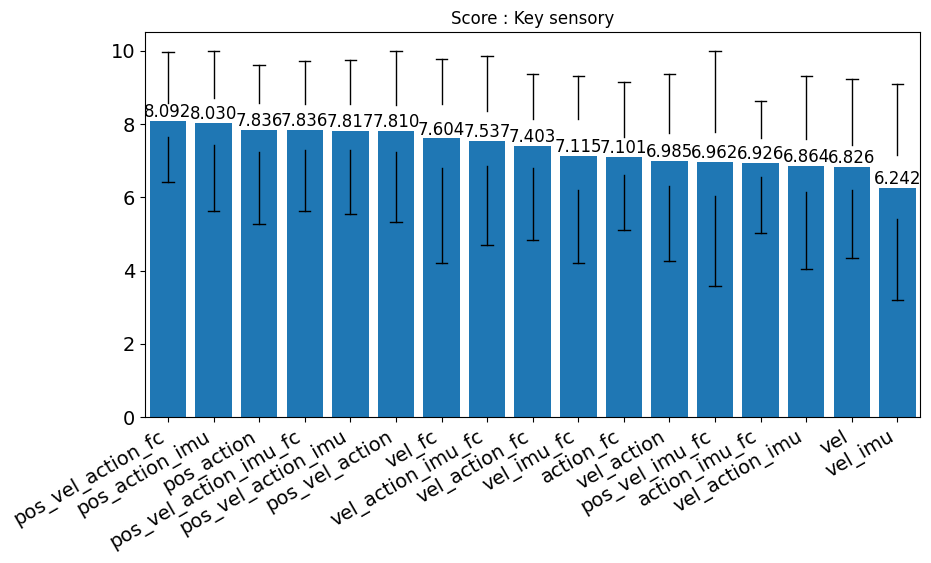

In [32]:
rank_meth = "value"
data_buff = copy.deepcopy(data)
# plot_case(data_buff["flat"],title="flat" , rank=rank_meth)
# plot_case(data_buff["morph"],title="morph" , rank=rank_meth)
# plot_case(data_buff["mass1000"],title="mass" , rank=rank_meth)
# plot_case(data_buff["rough"],title="rough" , rank=rank_meth)
# plot_case(data_buff["slope10"],title=r"slope $+10^{\circ}$" , rank=rank_meth)
# plot_case(data_buff["slope_10"],title=r"slope $-10^{\circ}$" , rank=rank_meth)

# del data_buff["flat"]
plot_ranking(data , title="Key sensory" , rank=rank_meth)
